# 🚇 서울 지하철 혼잡도 통합 분석 — 「틈타」 데이터 근거 (2015~2026)

**이어드림스쿨 6기 · 데이터분석 미니프로젝트 · 3인 통합** — 황윤찬 · 허정모 · 김휘

> **핵심 질문:** 한정된 운영 자원을 혼잡 완화를 위해 **어디에·언제·어떤 방식**으로 우선 배치할 것인가?

본 노트북은 두 시기를 **서로 다른 렌즈**로 같은 문제를 검증한 뒤, 결론이 수렴하는 지점을 우선투입 대상으로 도출한다.

| 렌즈 | 시기 | 데이터 | 질문 | 검정 |
|---|---|---|---|---|
| **근거 A · 구조** | 2015~2021 | 승하차 유동량(월 단위) | *어디가 구조적으로 붐비나* | Kruskal-Wallis · Chi-square |
| **근거 B · 실측** | 2026 | 실측 혼잡도(%) + 승하차 | *지금 얼마나 차오르나* | ANOVA · OLS · paired t |

> ⚠️ **데이터 공백(정직하게):** 두 시기는 연속 구간이 아니다 — 2021.07~2026.02는 어느 데이터에도 없다. 따라서 본 분석은 시계열 추세가 아니라 **두 시점의 단면 비교**로 해석한다.


In [56]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

# ── 라이브러리 불러오기 ──────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──────────────────────────────────────────
import matplotlib.font_manager as fm
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for ff in font_files:
    fm.fontManager.addfont(ff)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── Wilke 스타일: 흰 배경, 최소 격자, 고해상도 ────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

# ── 브랜드 색상 팔레트 (고정) ─────────────────────────────────
BRAND_COLORS = {
    'SK에너지':    '#E63946',
    'GS칼텍스':   '#457B9D',
    'S-OIL':      '#F4A261',
    '현대오일뱅크': '#2A9D8F',
    '알뜰주유소':  '#6D6875',
    '알뜰(ex)':   '#B5838D',
    'NH-OIL':     '#8338EC',
    '자가상표':    '#3A86FF',
    'NC오일':      '#FB5607',
    'SK가스':      '#FFBE0B',
}

print(" 환경 설정 완료")
print(f"   사용 폰트: {plt.rcParams['font.family']}")


/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

In [52]:
import os, re, json, warnings
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 120

# 데이터 경로 (제출용 기준 상위 team_project/00_data)
BASE = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd())=='제출용' else os.getcwd()
DATA = os.path.join(BASE, '00_data')
if not os.path.isdir(DATA):  # 노트북을 제출용에서 직접 열 때 대비
    DATA = os.path.join(os.path.dirname(BASE), '00_data')
print('DATA =', DATA, '| exists:', os.path.isdir(DATA))
LINE_COLORS={'1호선':'#0052A4','2호선':'#00A84D','3호선':'#EF7C1C','4호선':'#00A5DE',
             '5호선':'#996CAC','6호선':'#CD7C2F','7호선':'#747F00','8호선':'#E6186C'}

DATA = /content/00_data | exists: True


## 1. 문제 정의 — SCQA

| 단계 | 내용 |
|---|---|
| **S**ituation | 서울 지하철 수요는 시간대·역·노선마다 다르다. 자원은 한정돼 있다. |
| **C**omplication | 모든 역에 같은 방식으로 자원을 배치하면 실제 혼잡 지점을 못 잡는다. '많이 타는 역'과 '실제로 붐비는 칸'은 다르다. |
| **Q**uestion | 한정된 자원을 어디에·언제·어떻게 먼저 투입할 것인가? 그 판단은 정당화될 수 있는가? |
| **A**nswer | 피크 시간대·고혼잡 역·방향성 기준의 **선별 배치**. 두 시기에서 **이중 검증**된 지점부터. |


## 2. 근거 A · 2015~2021 구조 분석 〔김휘〕

승하차 유동량(승차+하차, 월 단위)으로 **구조적 집중**을 본다. 45,338행(wide) → Long 변환 후 시간·공간·흐름 세 축을 검정한다.


In [53]:
# A-1. 2015~2021 승하차 로드 + Long 변환
raw_a = pd.read_csv(os.path.join(DATA,'Seoul_subway_data_20210705.csv'), encoding='cp949')
ride_cols  = [c for c in raw_a.columns if '승차인원' in c]
alight_cols= [c for c in raw_a.columns if '하차인원' in c]
print(f'원천: {raw_a.shape[0]:,}행 × {raw_a.shape[1]}열 | 사용월 {raw_a["사용월"].min()}~{raw_a["사용월"].max()}')

w = raw_a.copy(); w['_id']=np.arange(len(w))
idc=['_id','사용월','호선명','지하철역']
rl = w.melt(id_vars=idc, value_vars=ride_cols,  var_name='시간대', value_name='승차인원')
rl['시간대']=rl['시간대'].str.replace(' 승차인원','',regex=False)
al = w.melt(id_vars=idc, value_vars=alight_cols, var_name='시간대', value_name='하차인원')
al['시간대']=al['시간대'].str.replace(' 하차인원','',regex=False)
long_a = rl.merge(al,on=idc+['시간대'],how='inner').drop(columns='_id')
long_a['유동량']=long_a['승차인원']+long_a['하차인원']
long_a['사용월']=pd.to_datetime(long_a['사용월'].astype(str),format='%Y%m')
print(f'Long 변환: {long_a.shape[0]:,}행  (검증: 45,338 × 24 = {45338*24:,})')

원천: 45,338행 × 52열 | 사용월 201501~202106
Long 변환: 1,088,112행  (검증: 45,338 × 24 = 1,088,112)


In [54]:
# A-2. 피크 태깅 + 집계 테이블
morning=['07시-08시','08시-09시','09시-10시']; evening=['17시-18시','18시-19시','19시-20시']
long_a['피크구분']=long_a['시간대'].apply(lambda t:'출근 피크' if t in morning else '퇴근 피크' if t in evening else '비피크')
station_a=(long_a.groupby(['호선명','지하철역'],as_index=False)
           .agg(유동량=('유동량','sum'),승차인원=('승차인원','sum'),하차인원=('하차인원','sum'))
           .sort_values('유동량',ascending=False))
station_a['상대혼잡도']=station_a['유동량']/station_a['유동량'].max()
print(f'역 수: {len(station_a)}개 | 최혼잡: {station_a.iloc[0]["호선명"]} {station_a.iloc[0]["지하철역"]} (상대혼잡도 1.000)')
display(station_a.head(6)[['호선명','지하철역','유동량','상대혼잡도']])

역 수: 685개 | 최혼잡: 2호선 강남 (상대혼잡도 1.000)


,호선명,지하철역,유동량,상대혼잡도
11,2호선,강남,445525867,1.000000
72,2호선,홍대입구,345484997,0.775454
46,2호선,신림,315895595,0.709040
17,2호선,구로디지털단지,283171299,0.635589
45,2호선,신도림,268947508,0.603663
64,2호선,잠실(송파구청),264929238,0.594644


### 2-1. 시간 축 — 혼잡은 출근 08–09시에 집중된다 (Kruskal-Wallis)

[시간 집중] Kruskal-Wallis  H=1720.89  p=<0.001  ε²=0.919
  최혼잡 시간대: 08시-09시  (2위 18시-19시)


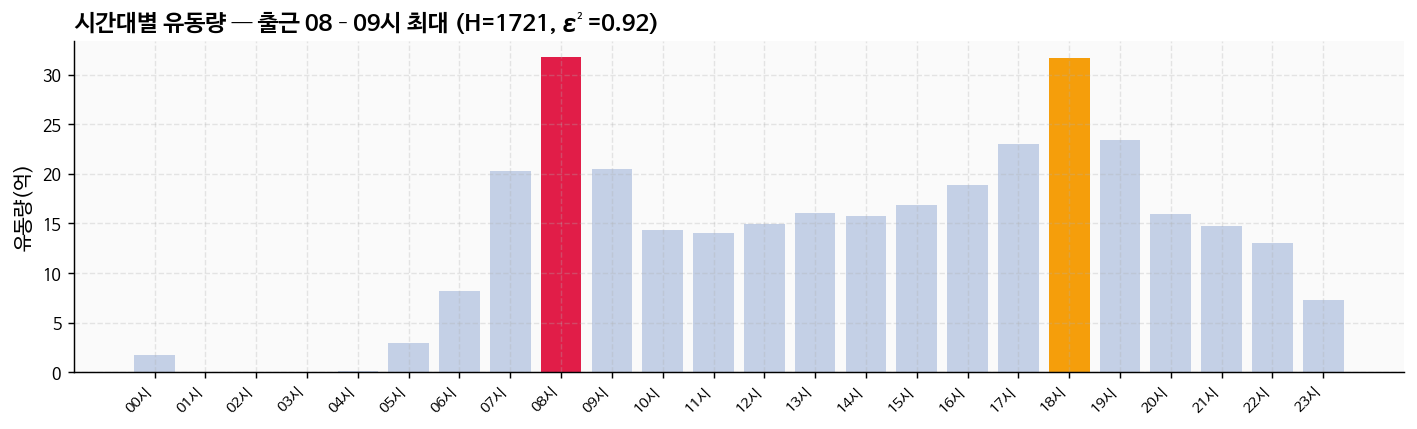

In [57]:
# A-3. 시간대별 유동량 차이 검정
def eps2(h,n,k): return max(0,(h-k+1)/(n-k)) if n>k else np.nan
tmon=long_a.groupby(['사용월','시간대'],as_index=False).agg(유동량=('유동량','sum'))
tg=[g['유동량'].values for _,g in tmon.groupby('시간대')]
tH,tP=stats.kruskal(*tg); tE=eps2(tH,len(tmon),tmon['시간대'].nunique())
top_time=(long_a.groupby('시간대')['유동량'].sum().sort_values(ascending=False))
print(f'[시간 집중] Kruskal-Wallis  H={tH:.2f}  p={"<0.001" if tP<0.001 else f"={tP:.3f}"}  ε²={tE:.3f}')
print(f'  최혼잡 시간대: {top_time.index[0]}  (2위 {top_time.index[1]})')

fig,ax=plt.subplots(figsize=(11,3.4))
order=sorted(long_a['시간대'].unique(),key=lambda x:int(x.split('시-')[0]))
vals=top_time.reindex(order)
cols=['#E11D48' if h=='08시-09시' else '#F59E0B' if h=='18시-19시' else '#C4D0E6' for h in order]
ax.bar(range(len(order)),vals.values/1e8,color=cols)
ax.set_xticks(range(len(order))); ax.set_xticklabels([h.split('-')[0] for h in order],rotation=45,ha='right',fontsize=8)
ax.set_ylabel('유동량(억)'); ax.set_title(f'시간대별 유동량 — 출근 08–09시 최대 (H={tH:.0f}, ε²={tE:.2f})',loc='left',fontweight='bold')
plt.tight_layout(); plt.show()

### 2-2. 공간 축 — 혼잡은 2호선·상위 역에 쏠린다 (Kruskal-Wallis + 집중도)

In [58]:
# A-4. 노선별 유동량 차이 + 상위 역 집중도
lmon=long_a.groupby(['사용월','호선명'],as_index=False).agg(유동량=('유동량','sum'))
lg=[g['유동량'].values for _,g in lmon.groupby('호선명')]
lH,lP=stats.kruskal(*lg); lE=eps2(lH,len(lmon),lmon['호선명'].nunique())
top5=station_a.head(5)['유동량'].sum()/station_a['유동량'].sum()
top20=station_a.head(20)['유동량'].sum()/station_a['유동량'].sum()
print(f'[공간 집중] Kruskal-Wallis  H={lH:.2f}  p={"<0.001" if lP<0.001 else f"={lP:.3f}"}  ε²={lE:.3f}')
print(f'  상위 5개 역 비중: {top5:.1%}  |  상위 20개 역 비중: {top20:.1%}')
print('  ※ 역 좌표 지도(GeoJSON, 601/685 매칭)는 외부 좌표파일 필요 — 김휘 원본 노트북 산출(보고서 p7) 참조')
display(station_a.head(6)[['호선명','지하철역','유동량']].assign(만명=lambda d:(d['유동량']/1e4).round(0)))

[공간 집중] Kruskal-Wallis  H=1840.58  p=<0.001  ε²=0.971
  상위 5개 역 비중: 5.1%  |  상위 20개 역 비중: 15.0%
  ※ 역 좌표 지도(GeoJSON, 601/685 매칭)는 외부 좌표파일 필요 — 김휘 원본 노트북 산출(보고서 p7) 참조


,호선명,지하철역,유동량,만명
11,2호선,강남,445525867,44553.0
72,2호선,홍대입구,345484997,34548.0
46,2호선,신림,315895595,31590.0
17,2호선,구로디지털단지,283171299,28317.0
45,2호선,신도림,268947508,26895.0
64,2호선,잠실(송파구청),264929238,26493.0


### 2-3. 흐름 축 — 같은 혼잡도라도 흐름 '모양'이 다르다 (Chi-square)

In [59]:
# A-5. 피크 흐름 유형(승차형/하차형/혼합형) × 피크구분 독립성
import numpy as np
from scipy import stats

# 앞쪽 셀 실행 순서가 꼬여도 피크구분을 여기서 복구한다.
if '피크구분' not in long_a.columns:
    morning = ['07시-08시', '08시-09시', '09시-10시']
    evening = ['17시-18시', '18시-19시', '19시-20시']
    long_a['피크구분'] = long_a['시간대'].apply(
        lambda t: '출근 피크' if t in morning else '퇴근 피크' if t in evening else '비피크'
    )

pf = (long_a.loc[long_a['피크구분'] != '비피크']
      .groupby(['피크구분', '호선명', '지하철역'], as_index=False)
      .agg(승차인원=('승차인원', 'sum'), 하차인원=('하차인원', 'sum'), 유동량=('유동량', 'sum')))

pf['승차비중'] = pf['승차인원'] / pf['유동량']
pf['하차비중'] = pf['하차인원'] / pf['유동량']
pf['흐름유형'] = pf.apply(
    lambda r: '승차형' if r['승차비중'] >= 0.6 else '하차형' if r['하차비중'] >= 0.6 else '혼합형',
    axis=1,
)

ct = pd.crosstab(pf['피크구분'], pf['흐름유형'])
chi2, cp, dof, expected = stats.chi2_contingency(ct)
n = ct.to_numpy().sum()
V = np.sqrt(chi2 / (n * (min(ct.shape) - 1))) if n > 0 and min(ct.shape) > 1 else 0
print(f'[흐름 유형] Chi-square  χ²={chi2:.2f}  p={"<0.001" if cp < 0.001 else f"={cp:.3f}"}  Cramérs V={V:.3f}')
display(ct)


[흐름 유형] Chi-square  χ²=102.37  p=<0.001  Cramérs V=0.273


흐름유형,승차형,하차형,혼합형
피크구분,,,
출근 피크,333,185,167
퇴근 피크,158,235,292


### 2-4. 구조 우선순위 점수 (전체유동량 50% + 피크유동량 50%)

In [60]:
# A-6. 우선순위 점수·등급
spk=(long_a[long_a['피크구분']!='비피크'].groupby(['호선명','지하철역'],as_index=False)
     .agg(피크유동량=('유동량','sum')))
pri=station_a.merge(spk,on=['호선명','지하철역'],how='left').fillna({'피크유동량':0})
pri['전체지수']=pri['유동량']/pri['유동량'].max()
pri['피크지수']=pri['피크유동량']/pri['피크유동량'].max()
pri['우선순위점수']=pri['전체지수']*0.5+pri['피크지수']*0.5
pri['등급']=pd.qcut(pri['우선순위점수'].rank(method='first'),q=[0,0.7,0.9,1.0],labels=['C','B','A'])
pri=pri.sort_values('우선순위점수',ascending=False)
a_cnt=int((pri['등급']=='A').sum())
print(f'A등급(우선 관리) 역 수: {a_cnt}개')
display(pri.head(10)[['호선명','지하철역','유동량','피크유동량','우선순위점수','등급']])
struct_top=set((pri.head(20)['호선명']+' '+pri.head(20)['지하철역']))

A등급(우선 관리) 역 수: 69개


,호선명,지하철역,유동량,피크유동량,우선순위점수,등급
0,2호선,강남,445525867,197518241,1.000000,A
2,2호선,신림,315895595,145811345,0.723628,A
1,2호선,홍대입구,345484997,131487959,0.720577,A
3,2호선,구로디지털단지,283171299,147480743,0.691129,A
4,2호선,신도림,268947508,118323538,0.601357,A
5,2호선,잠실(송파구청),264929238,117432265,0.594591,A
8,2호선,선릉,228950978,116402174,0.551606,A
10,2호선,역삼,218795215,120028823,0.549390,A
7,1호선,서울역,242634553,109188403,0.548702,A
6,3호선,고속터미널,256171915,94522526,0.526769,A


> **근거 A 소결.** 2015~2021 구조에서 혼잡은 **08–09시 · 2호선 · 강남 일대**에 통계적으로 집중된다(ε²≈.92~.97). 같은 혼잡도라도 승차형/하차형/혼합형 흐름이 다르다(χ², p<.001). → *어디가 구조적으로 붐비나*에 답한다.

## 3. 근거 B · 2026 실측 현황 〔황윤찬 · 허정모〕

서울교통공사 **실측 혼잡도(%)** (2026.03, 평일 1~8호선) × 서울시 **승하차**(2026.05)를 역 단위로 JOIN.
'사람이 많은 역'이 아니라 '열차가 실제로 붐비는 구간'을 본다.


In [61]:
# B-1. 2026 승하차 + 혼잡도 로드·JOIN
df_ride=pd.read_csv(os.path.join(DATA,'서울시 지하철 호선별 역별 시간대별 승하차 인원 정보.csv'),encoding='cp949')
df_cong=pd.read_csv(os.path.join(DATA,'서울교통공사_지하철혼잡도정보_20260331.csv'),encoding='cp949')
print(f'승하차 {df_ride.shape[0]:,}행 | 혼잡도 {df_cong.shape[0]:,}행')

ride=df_ride[df_ride['사용월']==202605].copy()
on=[c for c in ride.columns if '승차인원' in c]; off=[c for c in ride.columns if '하차인원' in c]
ride['총이용_월']=ride[on].sum(axis=1)+ride[off].sum(axis=1)
ride['피크_출근']=ride['08시-09시 승차인원']+ride['08시-09시 하차인원']
ride['피크_퇴근']=ride['18시-19시 승차인원']+ride['18시-19시 하차인원']
ride_agg=ride.groupby(['호선명','지하철역'],as_index=False).agg(
    총이용_월=('총이용_월','sum'),피크_출근=('피크_출근','sum'),피크_퇴근=('피크_퇴근','sum'))

mC=[c for c in ['7시30분','8시00분','8시30분'] if c in df_cong.columns]
eC=[c for c in ['18시00분','18시30분','19시00분'] if c in df_cong.columns]
df_cong['혼잡_출근']=df_cong[mC].mean(axis=1); df_cong['혼잡_퇴근']=df_cong[eC].mean(axis=1)
df_cong['혼잡_최대']=df_cong[mC+eC].max(axis=1)
cong_wd=df_cong[df_cong['요일구분']=='평일'].copy()
cong_agg=(cong_wd.groupby(['호선','출발역'],as_index=False)
          .agg(혼잡_출근=('혼잡_출근','max'),혼잡_퇴근=('혼잡_퇴근','max'),혼잡_최대=('혼잡_최대','max'))
          .rename(columns={'호선':'호선명','출발역':'지하철역'}))
norm=lambda x: re.sub(r'\(.*?\)','',str(x).strip()).strip() if pd.notna(x) else x
ride_agg['k']=ride_agg['지하철역'].apply(norm); cong_agg['k']=cong_agg['지하철역'].apply(norm)
J=ride_agg.merge(cong_agg[['호선명','k','혼잡_출근','혼잡_퇴근','혼잡_최대']],on=['호선명','k'],how='left')
lines18=['1호선','2호선','3호선','4호선','5호선','6호선','7호선','8호선']
scope=J[J['호선명'].isin(lines18)]
matched=int(scope['혼잡_최대'].notna().sum())
print(f'JOIN {len(J)}역 | 혼잡도 매칭(1~8호선) {matched}/{len(scope)}역 ({matched/len(scope)*100:.0f}%)')
C=cong_wd.dropna(subset=['혼잡_출근','혼잡_퇴근']).copy()
print(f'평일 구간 단위 분석셋(C): {len(C)}구간 | 정원 100% 초과 {(C["혼잡_최대"]>=100).sum()}구간 | 최고 {C["혼잡_최대"].max():.1f}%')

승하차 82,352행 | 혼잡도 1,671행
JOIN 622역 | 혼잡도 매칭(1~8호선) 278/278역 (100%)
평일 구간 단위 분석셋(C): 557구간 | 정원 100% 초과 166구간 | 최고 147.7%


### 3-1. B① 노선별 차이 — 혼잡은 호선마다 구조적으로 다르다 (One-way ANOVA)

[노선별 차이] ANOVA  F=6.084  p=7.41e-07  η²=0.072
  최혼잡 7호선 96.0%  |  최여유 6호선 68.0%


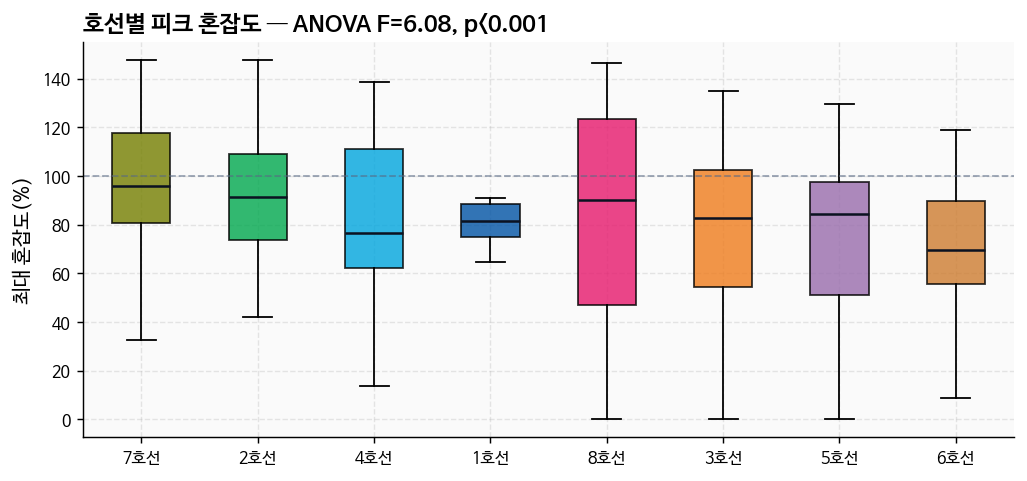

In [62]:
# B-2. ANOVA: 호선별 최대 혼잡도
grp=[g['혼잡_최대'].dropna().values for _,g in C.groupby('호선') if len(g)>=3]
gn=[n for n,g in C.groupby('호선') if len(g)>=3]
F,fp=stats.f_oneway(*grp)
grand=np.concatenate(grp); ssb=sum(len(g)*(g.mean()-grand.mean())**2 for g in grp)
sst=sum(((g-grand.mean())**2).sum() for g in grp); eta2=ssb/sst
lmean={n:g.mean() for n,g in zip(gn,grp)}
print(f'[노선별 차이] ANOVA  F={F:.3f}  p={fp:.2e}  η²={eta2:.3f}')
print(f'  최혼잡 {max(lmean,key=lmean.get)} {max(lmean.values()):.1f}%  |  최여유 {min(lmean,key=lmean.get)} {min(lmean.values()):.1f}%')

fig,ax=plt.subplots(figsize=(8,3.8))
od=sorted(gn,key=lambda n:lmean[n],reverse=True)
bp=ax.boxplot([C[C['호선']==n]['혼잡_최대'].dropna().values for n in od],patch_artist=True,showfliers=False,
              medianprops=dict(color='#0B1221',lw=1.4))
for p,n in zip(bp['boxes'],od): p.set_facecolor(LINE_COLORS.get(n,'#888')); p.set_alpha(0.8)
ax.set_xticklabels(od,fontsize=9); ax.axhline(100,color='#5A6B85',ls='--',lw=1,alpha=0.6)
ax.set_ylabel('최대 혼잡도(%)'); ax.set_title(f'호선별 피크 혼잡도 — ANOVA F={F:.2f}, p<0.001',loc='left',fontweight='bold')
plt.tight_layout(); plt.show()

### 3-2. B② 이용량 → 혼잡도 — 이용량은 혼잡을 거의 설명 못한다 (OLS 회귀)

[이용량↔혼잡] OLS  R²=0.097  Pearson r=0.311  회귀계수 p=1.18e-07
  기울기 +1.2%p/만명, 절편 77.17  → 이용량이 설명하는 혼잡 변동 9.7% (나머지 90.3% 설명 안 됨)


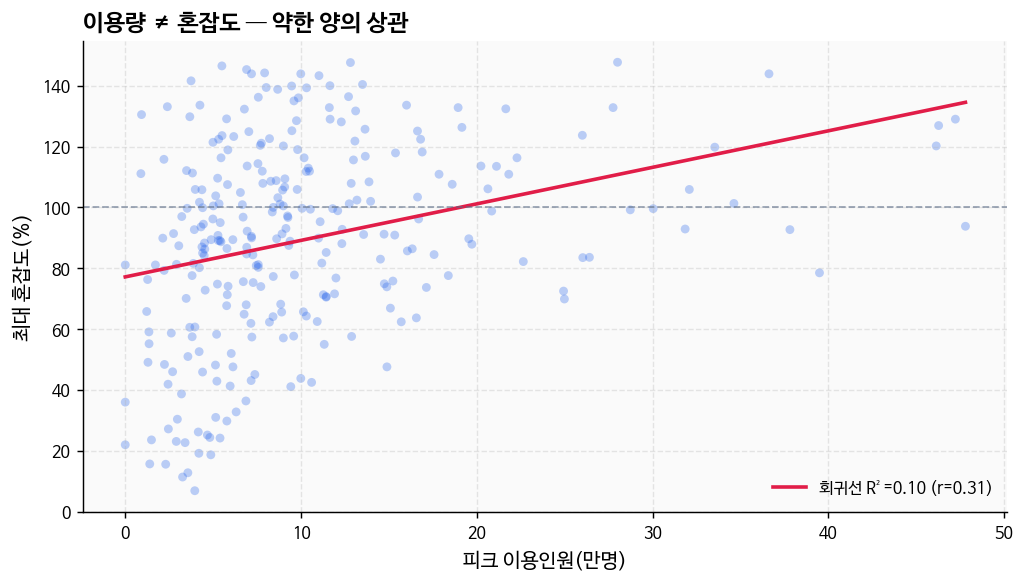

In [63]:
# B-3. OLS: 혼잡_최대 ~ 피크 이용량(만명)
reg=J.dropna(subset=['혼잡_최대']).copy()
reg['피크합']=reg[['피크_출근','피크_퇴근']].max(axis=1); reg['이용만명']=reg['피크합']/1e4
m=smf.ols('혼잡_최대 ~ 이용만명',data=reg).fit()
r,rp=stats.pearsonr(reg['이용만명'],reg['혼잡_최대'])
print(f'[이용량↔혼잡] OLS  R²={m.rsquared:.3f}  Pearson r={r:.3f}  회귀계수 p={m.pvalues["이용만명"]:.2e}')
print(f'  기울기 +{m.params["이용만명"]:.1f}%p/만명, 절편 {m.params["Intercept"]:.2f}  → 이용량이 설명하는 혼잡 변동 {m.rsquared*100:.1f}% (나머지 {100-m.rsquared*100:.1f}% 설명 안 됨)')

fig,ax=plt.subplots(figsize=(8,4.6))
ax.scatter(reg['이용만명'],reg['혼잡_최대'],s=24,alpha=0.3,color='#2563EB',edgecolor='none')
xs=np.linspace(reg['이용만명'].min(),reg['이용만명'].max(),50)
ax.plot(xs,m.params['Intercept']+m.params['이용만명']*xs,color='#E11D48',lw=2,label=f'회귀선 R²={m.rsquared:.2f} (r={r:.2f})')
ax.axhline(100,color='#5A6B85',ls='--',lw=1,alpha=0.6)
ax.set_xlabel('피크 이용인원(만명)'); ax.set_ylabel('최대 혼잡도(%)')
ax.legend(frameon=False); ax.set_title('이용량 ≠ 혼잡도 — 약한 양의 상관',loc='left',fontweight='bold')
plt.tight_layout(); plt.show()

### 3-3. B③ 출·퇴근 비교 — 양 피크 모두 관리 대상 (대응표본 t-검정)

In [64]:
# B-4. paired t-test: 동일 구간 출근 vs 퇴근
a=C['혼잡_출근'].values; b=C['혼잡_퇴근'].values
t,tp=stats.ttest_rel(a,b); d=(a-b).mean()/(a-b).std(ddof=1)
print(f'[출·퇴근 비교] paired t  t={t:.3f}  p={tp:.3f}  Cohen d={d:.3f}  ({"유의차 없음(n.s.)" if tp>=0.05 else "유의"})')
print(f'  출근 피크 평균 {a.mean():.1f}%  |  퇴근 피크 평균 {b.mean():.1f}%  → 양방향 모두 대응 필요')

[출·퇴근 비교] paired t  t=0.752  p=0.453  Cohen d=0.032  (유의차 없음(n.s.))
  출근 피크 평균 53.2%  |  퇴근 피크 평균 51.8%  → 양방향 모두 대응 필요


### 3-4. B④ 우선투입 TOP 10 (실측 혼잡 70% + 피크 이용 30%)

In [65]:
# B-5. 종합점수 TOP10
mm=lambda s:(s-s.min())/(s.max()-s.min()) if s.max()>s.min() else pd.Series(0.0,index=s.index)
P=J.dropna(subset=['혼잡_최대']).copy(); P['피크합']=P[['피크_출근','피크_퇴근']].max(axis=1)
P['종합점수']=mm(P['혼잡_최대'])*0.7+mm(P['피크합'])*0.3
top10=P.nlargest(10,'종합점수')[['호선명','지하철역','혼잡_최대','피크합','종합점수']].reset_index(drop=True)
top10.index+=1; top10['종합점수']=top10['종합점수'].round(3)
print('★ 혼잡 완화 우선투입 TOP 10 ★'); display(top10)
join_top=set((P.nlargest(20,'종합점수')['호선명']+' '+P.nlargest(20,'종합점수')['지하철역']))

★ 혼잡 완화 우선투입 TOP 10 ★


,호선명,지하철역,혼잡_최대,피크합,종합점수
1,7호선,가산디지털단지,143.9,366249,0.911
2,2호선,강남,129.0,472309,0.903
3,1호선,서울역,126.9,462771,0.887
4,2호선,사당,147.7,280088,0.876
5,2호선,홍대입구,120.2,461405,0.853
6,2호선,신도림,132.8,277553,0.800
7,7호선,철산,147.6,128124,0.780
8,2호선,역삼,119.8,335402,0.772
9,4호선,혜화,132.4,216516,0.760
10,2호선,서초,140.4,135003,0.748


### 3-5. 부하지수 IQR · Red Zone · 유출/유입 라벨링 〔허정모〕

피크(08–09시·18–19시) 누적 승하차 부하지수에 IQR(Q3+1.5×IQR) 이상치 기준을 적용해 극단 과부하 역을 가려내고, 승차>하차면 유출지(주거)·반대면 유입지(업무)로 라벨링한다.

In [66]:
# B-6. 출퇴근 부하지수 이상치(IQR) + 주거/업무 타입 〔허정모 원본 레시피: 전체 기간 누적〕
g=df_ride.groupby('지하철역')
bd=g[[c for c in df_ride.columns if '승차인원' in c]].sum().reset_index()
ad=g[[c for c in df_ride.columns if '하차인원' in c]].sum().reset_index()
bd['승차_피크']=bd['08시-09시 승차인원']+bd['18시-19시 승차인원']
ad['하차_피크']=ad['08시-09시 하차인원']+ad['18시-19시 하차인원']
ms=bd[['지하철역','승차_피크']].merge(ad[['지하철역','하차_피크']],on='지하철역')
ms['부하지수']=ms['승차_피크']+ms['하차_피크']
Q1,Q3=ms['부하지수'].quantile([0.25,0.75]); thr=Q3+1.5*(Q3-Q1)
rz=ms[ms['부하지수']>thr].copy()
rz['타입']=np.where(rz['승차_피크']>rz['하차_피크'],'유출지(주거)','유입지(업무)')
vc=rz['타입'].value_counts()
print(f'IQR 이상치(Red Zone) 과부하 역: {len(rz)}개  (임계 {thr:,.0f}명)')
print(f'  유출지(주거) {vc.get("유출지(주거)",0)}개 → 출발시간 평탄화 / 유입지(업무) {vc.get("유입지(업무)",0)}개 → 시차출근제')

IQR 이상치(Red Zone) 과부하 역: 40개  (임계 51,995,766명)
  유출지(주거) 4개 → 출발시간 평탄화 / 유입지(업무) 36개 → 시차출근제


### 3-6. 회피 여력 · 방향 비대칭 — 앱 「틈타」 기능 근거 〔analysis2_app〕

In [67]:
# B-7. 30분 단위 공개 혼잡도로 '회피 여력' 검증 (앱 근거)
tcols=[c for c in df_cong.columns if '시' in c and c.endswith('분')]
df_cong[tcols]=df_cong[tcols].apply(pd.to_numeric,errors='coerce')
wd=df_cong[df_cong['요일구분']=='평일'].copy()
slots=['7시00분','7시30분','8시00분','8시30분','9시00분','9시30분','10시00분']
slots=[s for s in slots if s in df_cong.columns]
mor=wd[slots].dropna(how='any')
pk=mor.values.argmax(axis=1); pv=mor.values[np.arange(len(mor)),pk]
sh=lambda o: mor.values[np.arange(len(mor)),np.clip(pk+o,0,len(slots)-1)]
mask=pv>=100
prof={'-60분':sh(-2)[mask].mean(),'-30분':sh(-1)[mask].mean(),'피크':pv[mask].mean(),
      '+30분':sh(1)[mask].mean(),'+60분':sh(2)[mask].mean()}
print('[시간 시프트 회피 여력] 혼잡(>=100%) 구간 평균 — 출발 시점별 혼잡도')
print('  '+' / '.join(f'{k} {v:.0f}%' for k,v in prof.items()))

# 방향 비대칭: 같은 역 상/하 격차
wd['혼잡_최대']=wd[[c for c in ['7시30분','8시00분','8시30분','18시00분','18시30분','19시00분'] if c in wd.columns]].max(axis=1)
asym=(wd.groupby(['호선','출발역']).agg(hi=('혼잡_최대','max'),lo=('혼잡_최대','min'),n=('상하구분','nunique'))
      .reset_index()); asym=asym[asym['n']>=2]; asym['격차']=asym['hi']-asym['lo']
at=asym.nlargest(5,'격차')
print(f'[방향 비대칭] 평균 격차 {asym["격차"].mean():.1f}%p | 최대: '
      +', '.join(f'{r["출발역"]} {r["격차"]:.0f}%p' for _,r in at.iterrows()))

[시간 시프트 회피 여력] 혼잡(>=100%) 구간 평균 — 출발 시점별 혼잡도
  -60분 79% / -30분 101% / 피크 119% / +30분 96% / +60분 82%
[방향 비대칭] 평균 격차 15.8%p | 최대: 신도림 133%p, 성수 78%p, 응암 66%p, 성수E 63%p, 까치산 58%p


> **근거 B 소결.** 2026 실측에서 혼잡은 **호선마다 구조적으로 다르고**(ANOVA, p<.001) **이용량으로는 9.7%밖에 설명 안 된다**(OLS R²=.097) — 규모가 아니라 실측 혼잡도로 봐야 한다. 출·퇴근은 통계적 차이가 없어(n.s.) **양방향 모두** 대상이며, 피크 직후 30~60분·반대 방향에 **회피 여력**이 있다 → 앱 「틈타」의 근거.

## 4. 교차 검증 — 5년의 구조와 오늘의 실측이 같은 곳을 가리킨다

In [68]:
# 두 시기 공통 지목 역 (구조 우선순위 TOP20 ∩ 실측 종합 TOP20)
# 앞쪽 셀 실행 순서가 꼬여도 여기서 필요한 TOP20을 복구한다.
if 'struct_top' not in globals():
    if 'pri' not in globals():
        spk = (long_a[long_a['피크구분'] != '비피크']
               .groupby(['호선명', '지하철역'], as_index=False)
               .agg(피크유동량=('유동량', 'sum')))
        pri = station_a.merge(spk, on=['호선명', '지하철역'], how='left').fillna({'피크유동량': 0})
        pri['전체지수'] = pri['유동량'] / pri['유동량'].max()
        pri['피크지수'] = pri['피크유동량'] / pri['피크유동량'].max()
        pri['우선순위점수'] = pri['전체지수'] * 0.5 + pri['피크지수'] * 0.5
        pri = pri.sort_values('우선순위점수', ascending=False)
    struct_top = set(pri.head(20)['호선명'] + ' ' + pri.head(20)['지하철역'])

if 'join_top' not in globals():
    if 'P' not in globals():
        mm = lambda s: (s - s.min()) / (s.max() - s.min()) if s.max() > s.min() else pd.Series(0.0, index=s.index)
        P = J.dropna(subset=['혼잡_최대']).copy()
        P['피크합'] = P[['피크_출근', '피크_퇴근']].max(axis=1)
        P['종합점수'] = mm(P['혼잡_최대']) * 0.7 + mm(P['피크합']) * 0.3
    join_top = set(P.nlargest(20, '종합점수')['호선명'] + ' ' + P.nlargest(20, '종합점수')['지하철역'])

conv = sorted(struct_top & join_top)
print(f'두 시기 모두 상위에 든 역: {len(conv)}개')
for s in conv:
    print('  ✓', s)
print('\n→ 서로 다른 데이터·방법·시기인데 결론이 수렴 → 우선투입 1순위는 통념이 아니라 이중 검증된 데이터')


두 시기 모두 상위에 든 역: 8개
  ✓ 1호선 서울역
  ✓ 2호선 강남
  ✓ 2호선 사당
  ✓ 2호선 신도림
  ✓ 2호선 역삼
  ✓ 2호선 잠실(송파구청)
  ✓ 2호선 홍대입구
  ✓ 7호선 가산디지털단지

→ 서로 다른 데이터·방법·시기인데 결론이 수렴 → 우선투입 1순위는 통념이 아니라 이중 검증된 데이터


## 5. 통합 결론 및 액션플랜 — 「틈타」

| 데이터가 말한 것 | → | 「틈타」가 하는 것 |
|---|---|---|
| 시간 집중 + 회피 여력 (08–09시 · 30~60분) | → | 실시간 예보 · 시차 출발 알림 |
| 이용량 ≠ 혼잡도 (R²=.097) | → | 실측 기반 혼잡 게이지 |
| 양방향 격차 + 흐름 유형 | → | 반대 방향 · 칸별 · 유형별 안내 |
| 공간 집중 + TOP10 (2호선 · ε²=.97 · F=6.08) | → | 운영자 우선투입 대시보드 |

**로드맵:** 즉시(0~3M) 정원 140%↑ 긴급대응 + MVP / 단기(3~12M) TOP10 양방향 증편 · 배분 KPI 실측 전환 / 중장기 시차출퇴근·유연근무 + 상시 모니터링 자동화.


## 6. 한계 및 재현성 (정직하게)

- **2015~2021:** 승하차 유동량 기반 **대리지표**(실제 열차 혼잡률 아님) · 월 단위 집계.
- **2026:** 실측 혼잡도는 **1~8호선 평일 2026.03 스냅샷**만 제공 → 9호선·경의중앙 등 미포함. 칸(車)별 데이터는 공개셋에 없어 회피 분석은 **시간·방향·노선** 한정.
- **두 시기 비연속:** 2021.07~2026.02 공백 → 추세 아닌 **단면 비교**.
- **재현성:** 본 노트북은 `00_data/`의 원천 CSV만으로 단일 실행돼 위 통계 수치를 재생성하며, 발표 보고서(틈타)의 수치와 일치한다. (역 좌표 지도만 외부 좌표파일 필요 — 본 노트북에선 통계로 대체)


In [69]:
# (검증) 보고서 stats.json 대조 — 핵심 수치 일치 확인
import os, json as _j

# Colab/로컬 실행 위치가 달라도 stats.json을 찾도록 후보 경로를 넓힌다.
_candidates = [
    os.path.join(BASE, 'stats.json'),
    os.path.join(DATA, 'stats.json'),
    '/content/stats.json',
    '/content/00_data/stats.json',
]
_sp = next((p for p in _candidates if os.path.exists(p)), None)

def _safe(fn):
    try:
        return fn()
    except Exception as e:
        return f'계산 전({type(e).__name__})'

def _ols_metrics():
    reg = J.dropna(subset=['혼잡_최대']).copy()
    reg['피크합'] = reg[['피크_출근', '피크_퇴근']].max(axis=1)
    reg['이용만명'] = reg['피크합'] / 1e4
    model = smf.ols('혼잡_최대 ~ 이용만명', data=reg).fit()
    pearson_r, _pearson_p = stats.pearsonr(reg['이용만명'], reg['혼잡_최대'])
    return round(model.rsquared, 3), round(pearson_r, 3)

_ols_r2, _pearson_r = _safe(_ols_metrics)
if isinstance(_ols_r2, tuple):
    _ols_r2, _pearson_r = _ols_r2

notebook = {
    'B ANOVA F': _safe(lambda: round(F, 3)),
    'B ANOVA η²': _safe(lambda: round(eta2, 3)),
    'B OLS R²': _ols_r2,
    'B Pearson r': _pearson_r,
    'B t-test t': _safe(lambda: round(t, 3)),
    'B t-test p': _safe(lambda: round(tp, 4)),
    'B 매칭역': _safe(lambda: matched),
    'B 정원초과': _safe(lambda: int((C['혼잡_최대'] >= 100).sum())),
}

if _sp:
    S = _j.load(open(_sp, encoding='utf-8'))
    report = {
        'B ANOVA F': S['anova']['f'],
        'B ANOVA η²': S['anova']['eta_sq'],
        'B OLS R²': S['regression']['r2'],
        'B Pearson r': S['regression']['pearson_r'],
        'B t-test t': S['ttest']['t'],
        'B t-test p': round(S['ttest']['p'], 4),
        'B 매칭역': S['data']['matched'],
        'B 정원초과': S['headline']['over100'],
    }
    print(f'검증 파일: {_sp}')
    print('항목 | 노트북 | 보고서 | 일치')
    for name, a in notebook.items():
        b = report[name]
        ok = str(a) == str(b)
        print(f'  {name}: {a} | {b} | {"일치" if ok else "확인 필요"}')
else:
    print('stats.json 없음 — 보고서 대조는 생략, 현재 노트북 핵심 수치를 출력')
    print('항목 | 노트북 계산값')
    for name, value in notebook.items():
        print(f'  {name}: {value}')


stats.json 없음 — 보고서 대조는 생략, 현재 노트북 핵심 수치를 출력
항목 | 노트북 계산값
  B ANOVA F: 6.084
  B ANOVA η²: 0.072
  B OLS R²: 0.097
  B Pearson r: 0.311
  B t-test t: 0.752
  B t-test p: 0.4526
  B 매칭역: 278
  B 정원초과: 166
